<a href="https://colab.research.google.com/github/diellzaracci/genpact-ml-detyra3/blob/main/sistemi_SOD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
# uploading dataset

from google.colab import files

uploaded = files.upload()

Saving duts_dataset.zip to duts_dataset (1).zip


In [36]:
# verifying dataset exists

import os

print(os.listdir())

['.config', 'duts_dataset', 'data_loader.py', '.gradio', '__pycache__', 'duts_dataset (1).zip', 'app.py', 'evaluate.py', 'train.py', 'checkpoints', 'european-shorthair-8601492_640 (1).jpg', 'duts_dataset.zip', 'outputs', 'european-shorthair-8601492_640.jpg', 'sod_model.py', 'sample_data']


In [37]:
# extracting dataset

import zipfile
import os

zip_path = "duts_dataset.zip"
extract_path = "duts_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed.")

Extraction completed.


In [34]:
# checking dataset structure

for root, dirs, files in os.walk("duts_dataset"):
    print(root, len(files))

duts_dataset 1
duts_dataset/DUTS-TR 0
duts_dataset/DUTS-TR/DUTS-TR-Mask 10553
duts_dataset/DUTS-TR/DUTS-TR-Image 10553
duts_dataset/DUTS-TE 0
duts_dataset/DUTS-TE/DUTS-TE-Mask 5019
duts_dataset/DUTS-TE/DUTS-TE-Image 5019


In [38]:
# creating project folders

folders = [
    "checkpoints",
    "outputs"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print(os.listdir())

['.config', 'duts_dataset', 'data_loader.py', '.gradio', '__pycache__', 'duts_dataset (1).zip', 'app.py', 'evaluate.py', 'train.py', 'checkpoints', 'european-shorthair-8601492_640 (1).jpg', 'duts_dataset.zip', 'outputs', 'european-shorthair-8601492_640.jpg', 'sod_model.py', 'sample_data']


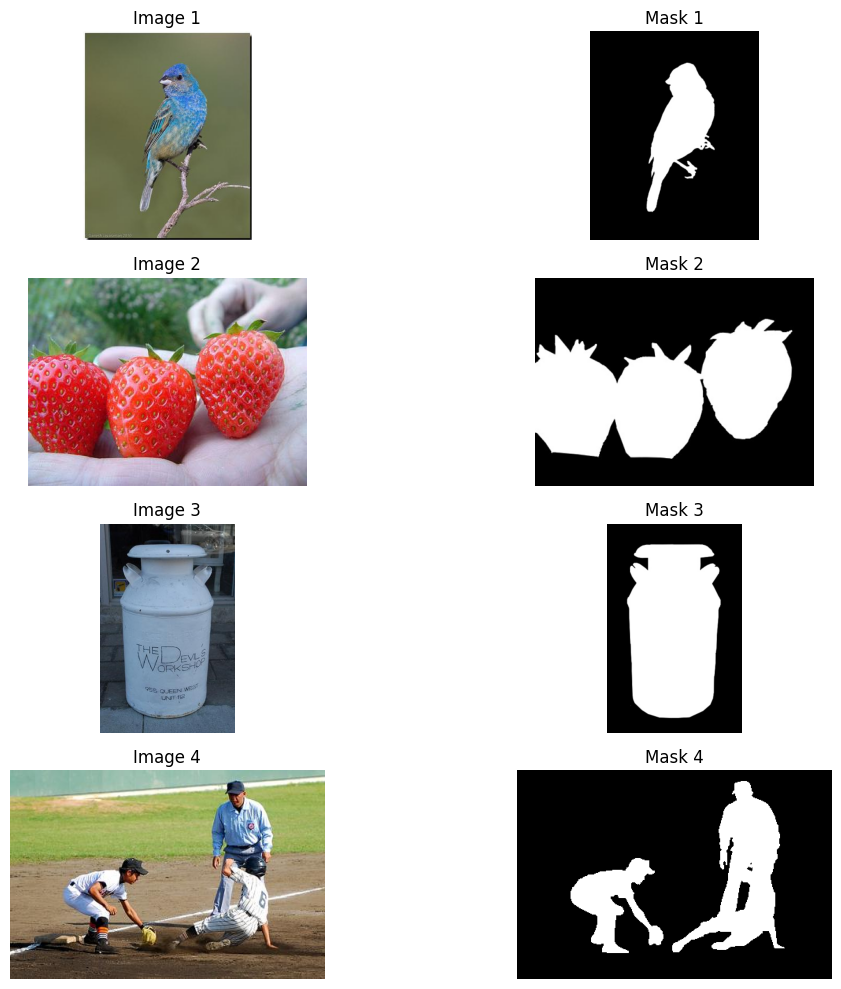

In [84]:
# visualizing some samples

import os
import cv2
import random
import matplotlib.pyplot as plt

image_dir = "duts_dataset/DUTS-TR/DUTS-TR-Image"
mask_dir = "duts_dataset/DUTS-TR/DUTS-TR-Mask"

# get random images
image_files = random.sample(os.listdir(image_dir), 4)

plt.figure(figsize=(12, 10))

for i, img_name in enumerate(image_files):

    base_name = os.path.splitext(img_name)[0]

    img_path = os.path.join(image_dir, img_name)
    mask_path = os.path.join(mask_dir, base_name + ".png")

    # read image
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # read mask
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # image subplot
    plt.subplot(4, 2, 2*i + 1)
    plt.imshow(image)
    plt.title(f"Image {i+1}")
    plt.axis("off")

    # mask subplot
    plt.subplot(4, 2, 2*i + 2)
    plt.imshow(mask, cmap="gray")
    plt.title(f"Mask {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [40]:
# installing required libraries

!pip install torch torchvision tqdm scikit-learn opencv-python

In [41]:
# creating data_loader.py

%%writefile data_loader.py

import os
import cv2
import torch
import random
import numpy as np

from torch.utils.data import Dataset, DataLoader, random_split


class DUTSDataset(Dataset):

    def __init__(self, image_dir, mask_dir, size=224, augment=False):

        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.size = size
        self.augment = augment

        self.images = sorted([
            f for f in os.listdir(image_dir)
            if f.endswith((".jpg", ".png", ".jpeg"))
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_name = self.images[idx]
        base_name = os.path.splitext(img_name)[0]

        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, base_name + ".png")

        # read image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # read mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # resize
        image = cv2.resize(image, (self.size, self.size))
        mask = cv2.resize(mask, (self.size, self.size))

        # normalize
        image = image.astype(np.float32) / 255.0
        mask = mask.astype(np.float32) / 255.0

        # augmentations
        if self.augment:

            # horizontal flip
            if random.random() > 0.5:
                image = np.fliplr(image).copy()
                mask = np.fliplr(mask).copy()

            # brightness variation
            if random.random() > 0.5:
                factor = random.uniform(0.8, 1.2)
                image = np.clip(image * factor, 0, 1)

        # convert to tensor
        image = torch.tensor(image).permute(2, 0, 1)
        mask = torch.tensor(mask).unsqueeze(0)

        return image, mask


def get_loaders(
    image_dir,
    mask_dir,
    batch_size=16,
    size=224
):

    full_dataset = DUTSDataset(
        image_dir=image_dir,
        mask_dir=mask_dir,
        size=size,
        augment=True
    )

    total_size = len(full_dataset)

    train_size = int(0.70 * total_size)
    val_size = int(0.15 * total_size)
    test_size = total_size - train_size - val_size

    train_dataset, val_dataset, test_dataset = random_split(
        full_dataset,
        [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )

    return train_loader, val_loader, test_loader

Overwriting data_loader.py


In [42]:
# testing data_loader

from data_loader import get_loaders

image_dir = "duts_dataset/DUTS-TR/DUTS-TR-Image"
mask_dir = "duts_dataset/DUTS-TR/DUTS-TR-Mask"

train_loader, val_loader, test_loader = get_loaders(
    image_dir=image_dir,
    mask_dir=mask_dir,
    batch_size=8,
    size=224
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 924
Validation batches: 198
Test batches: 198


In [43]:
# checking tensor shapes

images, masks = next(iter(train_loader))

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)

Images shape: torch.Size([8, 3, 224, 224])
Masks shape: torch.Size([8, 1, 224, 224])


In [65]:
%%writefile sod_model.py

import torch
import torch.nn as nn


class SODNet(nn.Module):

    def __init__(self):

        super(SODNet, self).__init__()

        # ENCODER

        self.encoder = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # DECODER

        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 1, kernel_size=2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):

        x = self.encoder(x)
        x = self.decoder(x)

        return x

Overwriting sod_model.py


In [45]:
# testing the sod_model

from sod_model import SODNet

model = SODNet()

sample_output = model(images)

print("Output shape:", sample_output.shape)

Output shape: torch.Size([8, 1, 224, 224])


In [66]:
# creating the training file

%%writefile train.py

import os
import torch
import torch.nn as nn
from tqdm import tqdm

from data_loader import get_loaders
from sod_model import SODNet


def iou_score(preds, masks, threshold=0.5):
    preds = (preds > threshold).float()
    masks = (masks > threshold).float()

    intersection = (preds * masks).sum()
    union = preds.sum() + masks.sum() - intersection

    return ((intersection + 1e-6) / (union + 1e-6)).item()


def total_loss(preds, masks):
    bce = nn.BCELoss()(preds, masks)

    intersection = (preds * masks).sum()
    union = preds.sum() + masks.sum() - intersection
    iou = (intersection + 1e-6) / (union + 1e-6)

    return bce + 0.5 * (1 - iou)


def train_model():
    image_dir = "duts_dataset/DUTS-TR/DUTS-TR-Image"
    mask_dir = "duts_dataset/DUTS-TR/DUTS-TR-Mask"

    train_loader, val_loader, test_loader = get_loaders(
        image_dir=image_dir,
        mask_dir=mask_dir,
        batch_size=16,
        size=224
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    model = SODNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    os.makedirs("checkpoints", exist_ok=True)



    checkpoint_path = "checkpoints/last_checkpoint.pth"
    best_model_path = "checkpoints/best_model.pth"

    start_epoch = 0
    best_val_loss = float("inf")

    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint["model_state"])
        optimizer.load_state_dict(checkpoint["optimizer_state"])
        start_epoch = checkpoint["epoch"] + 1
        best_val_loss = checkpoint["best_val_loss"]
        print(f"Resuming from epoch {start_epoch + 1}")

    epochs = 25
    patience = 5
    patience_counter = 0

    for epoch in range(start_epoch, epochs):
        model.train()
        train_loss = 0
        train_iou = 0

        for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = total_loss(outputs, masks)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_iou += iou_score(outputs.detach(), masks)

        train_loss /= len(train_loader)
        train_iou /= len(train_loader)

        model.eval()
        val_loss = 0
        val_iou = 0

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device)

                outputs = model(images)
                loss = total_loss(outputs, masks)

                val_loss += loss.item()
                val_iou += iou_score(outputs, masks)

        val_loss /= len(val_loader)
        val_iou /= len(val_loader)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train IoU: {train_iou:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val IoU: {val_iou:.4f}"
        )

        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "best_val_loss": best_val_loss
        }, checkpoint_path)

        print("Checkpoint saved.")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), best_model_path)
            print("Best model saved.")
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break


if __name__ == "__main__":
    train_model()

Overwriting train.py


In [67]:
!nvidia-smi

Fri May  8 13:17:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             48W /  400W |     532MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [68]:
# running training

!python train.py

Using device: cuda
Epoch 1/25: 100% 462/462 [00:10<00:00, 42.40it/s]
Epoch 1/25 | Train Loss: 0.8094 | Train IoU: 0.3856 | Val Loss: 0.8055 | Val IoU: 0.3299
Checkpoint saved.
Best model saved.
Epoch 2/25: 100% 462/462 [00:10<00:00, 43.21it/s]
Epoch 2/25 | Train Loss: 0.7657 | Train IoU: 0.4203 | Val Loss: 0.7664 | Val IoU: 0.4074
Checkpoint saved.
Best model saved.
Epoch 3/25: 100% 462/462 [00:10<00:00, 43.61it/s]
Epoch 3/25 | Train Loss: 0.7487 | Train IoU: 0.4362 | Val Loss: 0.7554 | Val IoU: 0.3999
Checkpoint saved.
Best model saved.
Epoch 4/25: 100% 462/462 [00:10<00:00, 43.54it/s]
Epoch 4/25 | Train Loss: 0.7320 | Train IoU: 0.4530 | Val Loss: 0.7467 | Val IoU: 0.4337
Checkpoint saved.
Best model saved.
Epoch 5/25: 100% 462/462 [00:10<00:00, 43.60it/s]
Epoch 5/25 | Train Loss: 0.7154 | Train IoU: 0.4686 | Val Loss: 0.7463 | Val IoU: 0.4762
Checkpoint saved.
Best model saved.
Epoch 6/25: 100% 462/462 [00:10<00:00, 43.17it/s]
Epoch 6/25 | Train Loss: 0.7009 | Train IoU: 0.4824 | Va

In [69]:
# checking that best model exists

import os

print(os.listdir("checkpoints"))

['best_model_lr1e4.pth', 'last_checkpoint_lr1e4.pth', 'best_model.pth', 'best_model_experiment2.pth', 'last_checkpoint_experiment2.pth', 'last_checkpoint.pth']


In [71]:
# creating evaluate.py

%%writefile evaluate.py

import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from data_loader import get_loaders
from sod_model import SODNet


def calculate_metrics(preds, masks, threshold=0.5):
    preds_bin = (preds > threshold).float()
    masks_bin = (masks > threshold).float()

    tp = (preds_bin * masks_bin).sum()
    fp = (preds_bin * (1 - masks_bin)).sum()
    fn = ((1 - preds_bin) * masks_bin).sum()

    precision = (tp + 1e-6) / (tp + fp + 1e-6)
    recall = (tp + 1e-6) / (tp + fn + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)

    intersection = (preds_bin * masks_bin).sum()
    union = preds_bin.sum() + masks_bin.sum() - intersection
    iou = (intersection + 1e-6) / (union + 1e-6)

    mae = torch.abs(preds - masks).mean()

    return iou.item(), precision.item(), recall.item(), f1.item(), mae.item()


def evaluate_model():
    image_dir = "duts_dataset/DUTS-TR/DUTS-TR-Image"
    mask_dir = "duts_dataset/DUTS-TR/DUTS-TR-Mask"

    _, _, test_loader = get_loaders(
        image_dir=image_dir,
        mask_dir=mask_dir,
        batch_size=8,
        size=224
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    model = SODNet().to(device)
    model.load_state_dict(torch.load("checkpoints/best_model.pth", map_location=device))
    model.eval()

    total_iou = 0
    total_precision = 0
    total_recall = 0
    total_f1 = 0
    total_mae = 0

    os.makedirs("outputs", exist_ok=True)

    with torch.no_grad():
        for batch_idx, (images, masks) in enumerate(test_loader):
            images = images.to(device)
            masks = masks.to(device)

            preds = model(images)

            iou, precision, recall, f1, mae = calculate_metrics(preds, masks)

            total_iou += iou
            total_precision += precision
            total_recall += recall
            total_f1 += f1
            total_mae += mae

            if batch_idx == 0:
                for i in range(min(4, images.size(0))):
                    img = images[i].cpu().permute(1, 2, 0).numpy()
                    gt = masks[i].cpu().squeeze().numpy()
                    pred = preds[i].cpu().squeeze().numpy()

                    overlay = img.copy()
                    overlay[:, :, 0] = np.maximum(overlay[:, :, 0], pred)

                    plt.figure(figsize=(12, 4))

                    plt.subplot(1, 4, 1)
                    plt.imshow(img)
                    plt.title("Input")
                    plt.axis("off")

                    plt.subplot(1, 4, 2)
                    plt.imshow(gt, cmap="gray")
                    plt.title("Ground Truth")
                    plt.axis("off")

                    plt.subplot(1, 4, 3)
                    plt.imshow(pred, cmap="gray")
                    plt.title("Prediction")
                    plt.axis("off")

                    plt.subplot(1, 4, 4)
                    plt.imshow(overlay)
                    plt.title("Overlay")
                    plt.axis("off")

                    plt.savefig(f"outputs/sample_{i}.png")
                    plt.show()

    n = len(test_loader)

    print("Final Test Results")
    print(f"IoU: {total_iou / n:.4f}")
    print(f"Precision: {total_precision / n:.4f}")
    print(f"Recall: {total_recall / n:.4f}")
    print(f"F1-score: {total_f1 / n:.4f}")
    print(f"MAE: {total_mae / n:.4f}")


if __name__ == "__main__":
    evaluate_model()

Overwriting evaluate.py


In [72]:
# running evaluation

!python evaluate.py

Using device: cuda
Figure(1200x400)
Figure(1200x400)
Figure(1200x400)
Figure(1200x400)
Final Test Results
IoU: 0.5316
Precision: 0.7003
Recall: 0.6915
F1-score: 0.6906
MAE: 0.2084


In [64]:
# checking what files exist in checkpoints

import os

print(os.listdir("checkpoints"))

['best_model_lr1e4.pth', 'last_checkpoint_lr1e4.pth', 'best_model_experiment2.pth', 'last_checkpoint_experiment2.pth']


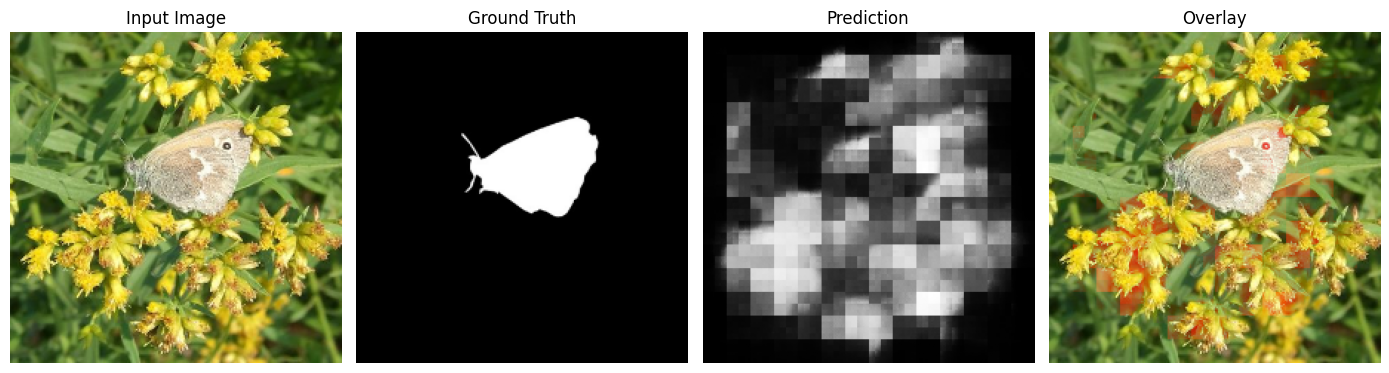

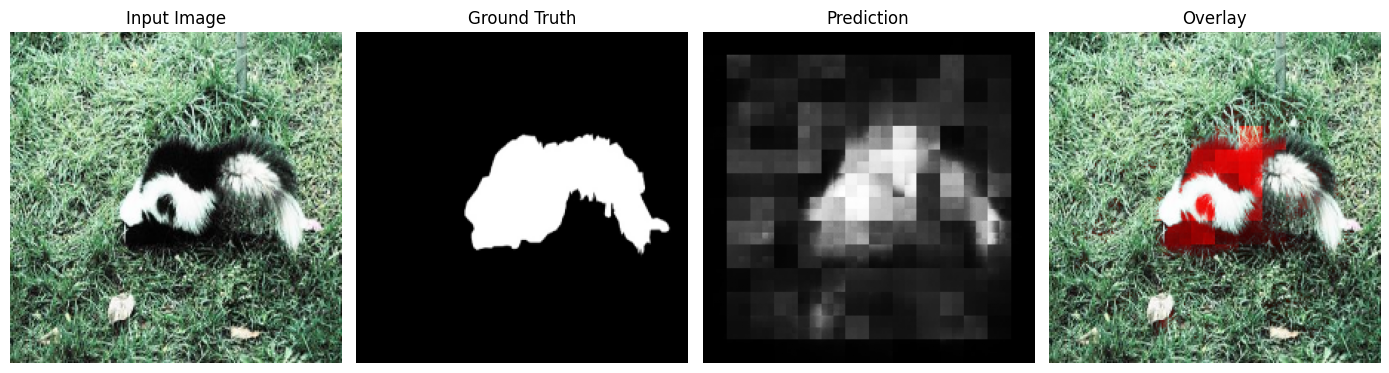

In [106]:
# Random visualization of 2 samples

import torch
import numpy as np
import matplotlib.pyplot as plt
import random

from data_loader import get_loaders
from sod_model import SODNet

image_dir = "duts_dataset/DUTS-TR/DUTS-TR-Image"
mask_dir = "duts_dataset/DUTS-TR/DUTS-TR-Mask"

_, _, test_loader = get_loaders(
    image_dir=image_dir,
    mask_dir=mask_dir,
    batch_size=16,
    size=224
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SODNet().to(device)

model.load_state_dict(
    torch.load("checkpoints/best_model.pth", map_location=device)
)

model.eval()

images, masks = next(iter(test_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    preds = model(images)

random_indices = random.sample(range(len(images)), 2)

for idx, i in enumerate(random_indices):

    img = images[i].cpu().permute(1, 2, 0).numpy()
    gt = masks[i].cpu().squeeze().numpy()
    pred = preds[i].cpu().squeeze().numpy()

    overlay = img.copy()

    overlay[:, :, 0] = np.maximum(
        overlay[:, :, 0],
        pred
    )

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(img)
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(gt, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(pred, cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.tight_layout()

    plt.savefig(f"outputs/random_visualization_{idx+1}.png")

    plt.show()

Saving european-shorthair-8601492_640.jpg to european-shorthair-8601492_640 (2).jpg


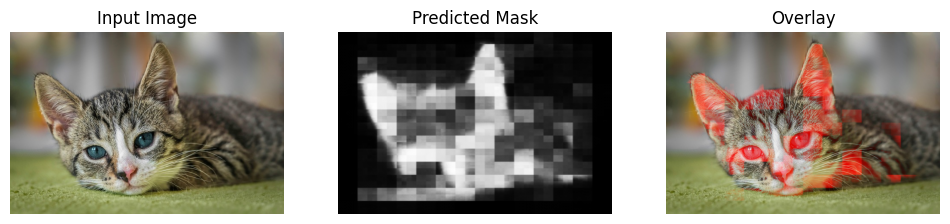

Inference Time: 0.0023 seconds


In [76]:
# demo

from google.colab import files
import time
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from sod_model import SODNet

uploaded = files.upload()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SODNet().to(device)

model.load_state_dict(
    torch.load("checkpoints/best_model.pth", map_location=device)
)

model.eval()

for filename in uploaded.keys():

    image = cv2.imread(filename)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    original = image.copy()

    image_resized = cv2.resize(image, (224, 224))
    image_resized = image_resized.astype(np.float32) / 255.0

    tensor = torch.tensor(image_resized).permute(2, 0, 1)
    tensor = tensor.unsqueeze(0).to(device)

    start = time.time()

    with torch.no_grad():
        pred = model(tensor)

    end = time.time()

    pred_mask = pred.cpu().squeeze().numpy()

    pred_mask_resized = cv2.resize(
        pred_mask,
        (original.shape[1], original.shape[0])
    )

    overlay = original.astype(np.float32) / 255.0

    overlay[:, :, 0] = np.maximum(
        overlay[:, :, 0],
        pred_mask_resized
    )

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(original)
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(pred_mask_resized, cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.show()

    print(f"Inference Time: {end - start:.4f} seconds")

In [54]:
#installing gradio

!pip install gradio

In [81]:
# app.py

%%writefile app.py

import time
import cv2
import torch
import numpy as np
import gradio as gr

from sod_model import SODNet


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SODNet().to(device)
model.load_state_dict(torch.load("checkpoints/best_model.pth", map_location=device))
model.eval()


def predict_saliency(image):
    original = image.copy()

    resized = cv2.resize(image, (224, 224))
    normalized = resized.astype(np.float32) / 255.0

    tensor = torch.tensor(normalized).permute(2, 0, 1).unsqueeze(0).to(device)

    start = time.time()

    with torch.no_grad():
        pred = model(tensor)

    end = time.time()

    mask = pred.cpu().squeeze().numpy()
    mask_resized = cv2.resize(mask, (original.shape[1], original.shape[0]))

    mask_display = (mask_resized * 255).astype(np.uint8)

    overlay = original.astype(np.float32) / 255.0
    overlay[:, :, 0] = np.maximum(overlay[:, :, 0], mask_resized)
    overlay = (overlay * 255).astype(np.uint8)

    inference_time = f"{end - start:.4f} seconds"

    return mask_display, overlay, inference_time


demo = gr.Interface(
    fn=predict_saliency,

    inputs=gr.Image(
        type="numpy",
        label="Upload Image"
    ),

    outputs=[
        gr.Image(type="numpy", label="Predicted Saliency Mask"),
        gr.Image(type="numpy", label="Overlay"),
        gr.Textbox(label="Inference Time")
    ],

    title="Salient Object Detection Demo",

    description="""
Upload an image and the CNN model will predict the salient object mask.

Created by Diellza Raçi
""",

    css="""
    button.primary {
        background: #14532d !important;
        border: none !important;
        color: white !important;
    }

    button.primary:hover {
        background: #166534 !important;
    }
    """
)


demo.launch(share=True)

Overwriting app.py


In [82]:
# run app.py

!python app.py

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://93f901d2317a0387d4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
Keyboard interruption in main thread... closing server.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 3043, in block_thread
    time.sleep(0.1)
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/content/app.py", line 83, in <module>
    demo.launch(share=True)
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2950, in launch
    self.block_thread()
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 3047, in block_thread
    self.server.close()
  File "/usr/local/lib/python3.12/dist-packages